# **Data Cleaning and Standardization**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd # data analysis and manipulation
import numpy as np # maths equations
import plotly.graph_objects as go # for 3D visualization
import plotly.express as px # for 3D visualization
import plotly.figure_factory as ff
from scipy.stats import norm, skew # for statistical analysis
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#Model Building
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [ ]:
# Loading the dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/kalimati-tarkari-prices-from-may-2021-to-september-2023.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Data exploration
print("Dataset shape: " , df.shape)
print("\nColumn Names and Data Types:")
print(df.dtypes)
print("\nFirst Few Rows of the Dataset:")
print(df.head())
print("\nLast Few Rows of the Dataset: ")
print(df.tail())
print("\nSummary Statistics: ")
print(df.describe(include = 'all'))

Dataset shape:  (96479, 6)

Column Names and Data Types:
Tomato Big(Nepali)    object
1/5/2021              object
Kg                    object
50                    object
60                    object
55                    object
dtype: object

First Few Rows of the Dataset:
     Tomato Big(Nepali)  1/5/2021  Kg  50  60    55
0    Tomato Big(Indian)  1/5/2021  Kg  50  60    55
1   Tomato Small(Local)  1/5/2021  Kg  30  35  32.5
2  Tomato Small(Tunnel)  1/5/2021  Kg  30  35  32.5
3  Tomato Small(Indian)  1/5/2021  KG  40  45  42.5
4   Tomato Small(Terai)  1/5/2021  KG  40  45  42.5

Last Few Rows of the Dataset: 
         Tomato Big(Nepali)    1/5/2021  Kg        50        60        55
96474  Tomato Small(Indian)  2023-09-28  KG  Rs 45.00  Rs 55.00  Rs 50.00
96475   Tomato Small(Local)  2023-09-28  KG  Rs 50.00  Rs 60.00  Rs 55.00
96476  Tomato Small(Tunnel)  2023-09-28  KG  Rs 60.00  Rs 75.00  Rs 69.00
96477              Turnip A  2023-09-28  KG  Rs 70.00  Rs 80.00  Rs 75.00
96478    

In [ ]:
# Providing names to columns
column_names = ['Vegetable','Date', 'Unit', 'Minimum Price' , 'Maximum Price', 'Average Price' ]


df = pd.read_csv('/content/drive/MyDrive/kalimati-tarkari-prices-from-may-2021-to-september-2023.csv', header = None, names = column_names, parse_dates=['Date'])

In [ ]:
df.isnull().sum()

,0
Vegetable,0
Date,0
Unit,0
Minimum Price,0
Maximum Price,0
Average Price,0


In [ ]:
print(df.head())
print(df.tail())

              Vegetable      Date Unit Minimum Price Maximum Price  \
0    Tomato Big(Nepali)  1/5/2021   Kg            50            60   
1    Tomato Big(Indian)  1/5/2021   Kg            50            60   
2   Tomato Small(Local)  1/5/2021   Kg            30            35   
3  Tomato Small(Tunnel)  1/5/2021   Kg            30            35   
4  Tomato Small(Indian)  1/5/2021   KG            40            45   

  Average Price  
0            55  
1            55  
2          32.5  
3          32.5  
4          42.5  
                  Vegetable        Date Unit Minimum Price Maximum Price  \
96475  Tomato Small(Indian)  2023-09-28   KG      Rs 45.00      Rs 55.00   
96476   Tomato Small(Local)  2023-09-28   KG      Rs 50.00      Rs 60.00   
96477  Tomato Small(Tunnel)  2023-09-28   KG      Rs 60.00      Rs 75.00   
96478              Turnip A  2023-09-28   KG      Rs 70.00      Rs 80.00   
96479    Water Melon(Green)  2023-09-28   KG      Rs 50.00      Rs 60.00   

      Average 

In [ ]:
# Parsing data to handle already correct date format YYYY-MM-DD
df['Parsed_Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# To handle unparsed data
mask_failed = df['Parsed_Date'].isna()

# Converts DD-MM-YYYY to YYYY-MM-DD
df.loc[mask_failed, 'Parsed_Date'] = pd.to_datetime(df.loc[mask_failed, 'Date'], errors='coerce', dayfirst=True)

# Formatting entire parsed datetime into 'YYYY-MM-DD' (datetime to String Object)
df['Date'] = df['Parsed_Date'].dt.strftime('%Y-%m-%d')

# Dropping helper column to avoid redundancy
df.drop(columns=['Parsed_Date'], inplace=True)

df.dtypes


,0
Vegetable,object
Date,object
Unit,object
Minimum Price,object
Maximum Price,object
Average Price,object


In [ ]:
# Converting Price Columns into numerical values removing units
price_cols =  ['Minimum Price' , 'Maximum Price' , 'Average Price']

# Looping through each row in price_cols and removing 'Rs' along with unnecessary white spaces using strip()
# changing the data types into float from object
for col in price_cols:
  df[col] = df[col].astype(str) # ensuring the values are strings
  df[col] = df[col].str.replace('Rs','',regex = False).str.strip()
  df[col] = df[col].str.strip() # to remove whitespaces
  df[col] = pd.to_numeric(df[col], errors='coerce') # Converting cleaned strings into numeric (float) values

In [ ]:
df.tail()

,Vegetable,Date,Unit,Minimum Price,Maximum Price,Average Price
96475,Tomato Small(Indian),NaN,KG,45.0,55.0,50.00
96476,Tomato Small(Local),NaN,KG,50.0,60.0,55.00
96477,Tomato Small(Tunnel),NaN,KG,60.0,75.0,69.00
96478,Turnip A,NaN,KG,70.0,80.0,75.00
96479,Water Melon(Green),NaN,KG,50.0,60.0,56.67


In [ ]:
df.head()

,Vegetable,Date,Unit,Minimum Price,Maximum Price,Average Price
0,Tomato Big(Nepali),2021-01-05,Kg,50.0,60.0,55.0
1,Tomato Big(Indian),2021-01-05,Kg,50.0,60.0,55.0
2,Tomato Small(Local),2021-01-05,Kg,30.0,35.0,32.5
3,Tomato Small(Tunnel),2021-01-05,Kg,30.0,35.0,32.5
4,Tomato Small(Indian),2021-01-05,KG,40.0,45.0,42.5


In [ ]:
print(df.dtypes)

Vegetable         object
Date              object
Unit              object
Minimum Price    float64
Maximum Price    float64
Average Price    float64
dtype: object


In [ ]:
# Logical Issue: Min > Max
invalid_logic = df[df['Minimum Price'] > df['Maximum Price']]
print(f"Rows with Minimum Price > Maximum Price: {len(invalid_logic)}")

# Outlier Detection using IQR
Q1 = df[['Minimum Price', 'Maximum Price', 'Average Price']].quantile(0.25)
Q3 = df[['Minimum Price', 'Maximum Price', 'Average Price']].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[['Minimum Price', 'Maximum Price', 'Average Price']] < (Q1 - 1.5 * IQR)) |
            (df[['Minimum Price', 'Maximum Price', 'Average Price']] > (Q3 + 1.5 * IQR)))

print("\nOutlier counts:")
print(outliers.sum())

Rows with Minimum Price > Maximum Price: 22

Outlier counts:
Minimum Price    5174
Maximum Price    4349
Average Price    5100
dtype: int64


In [ ]:
print(df['Unit'].value_counts()) # to see the different units

Unit
KG           55421
Kg           38840
1 Pc          1104
Per Dozen      524
Doz            465
Per Piece      126
Name: count, dtype: int64


In [ ]:
# Standardizing KG to Kg
df['Unit'] = df['Unit'].str.strip()

# Converting upper to lower case
df['Unit'] = df['Unit'].replace('KG','Kg')

In [ ]:
print(df['Unit'].value_counts())

Unit
Kg           94261
1 Pc          1104
Per Dozen      524
Doz            465
Per Piece      126
Name: count, dtype: int64


In [ ]:
df.head()

,Vegetable,Date,Unit,Minimum Price,Maximum Price,Average Price
0,Tomato Big(Nepali),2021-01-05,Kg,50.0,60.0,55.0
1,Tomato Big(Indian),2021-01-05,Kg,50.0,60.0,55.0
2,Tomato Small(Local),2021-01-05,Kg,30.0,35.0,32.5
3,Tomato Small(Tunnel),2021-01-05,Kg,30.0,35.0,32.5
4,Tomato Small(Indian),2021-01-05,Kg,40.0,45.0,42.5


In [ ]:
# Feature Engineering
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month # Extracting Month and Day from the already cleaned Date column
df['Day'] = df['Date'].dt.day
df['Price Range'] = df['Maximum Price'] - df['Minimum Price']

# Checking the new columns
df.head()

,Vegetable,Date,Unit,Minimum Price,Maximum Price,Average Price,Month,Day,Price Range
0,Tomato Big(Nepali),2021-01-05,Kg,50.0,60.0,55.0,1.0,5.0,10.0
1,Tomato Big(Indian),2021-01-05,Kg,50.0,60.0,55.0,1.0,5.0,10.0
2,Tomato Small(Local),2021-01-05,Kg,30.0,35.0,32.5,1.0,5.0,5.0
3,Tomato Small(Tunnel),2021-01-05,Kg,30.0,35.0,32.5,1.0,5.0,5.0
4,Tomato Small(Indian),2021-01-05,Kg,40.0,45.0,42.5,1.0,5.0,5.0


In [ ]:
#Saving the cleaned data as a csv file
#df.to_csv('kalimati_cleaned.csv', index=False, float_format='%.2f')

# Data Transformation and Reduction using Statistics


In [ ]:
import pandas as pd

# Load the cleaned CSV file
df = pd.read_csv("/content/drive/MyDrive/kalimati_cleaned .csv")

# Counting the number of unique vegetables
unique_vegetables = df['Vegetable'].nunique()

# List them:
vegetable_list = df['Vegetable'].unique()

print("Number of unique vegetables:", unique_vegetables)
print("List of vegetables:", vegetable_list)

Number of unique vegetables: 133
List of vegetables: ['Tomato Big(Nepali)' 'Tomato Big(Indian)' 'Tomato Small(Local)'
 'Tomato Small(Tunnel)' 'Tomato Small(Indian)' 'Tomato Small(Terai)'
 'Potato Red' 'Potato Red(Indian)' 'Potato White' 'Onion Dry (Indian)'
 'Carrot(Local)' 'Carrot(Terai)' 'Cabbage(Local)' 'Cabbage(Terai)'
 'Cabbage' 'Cauli Local' 'Cauli Local(Jyapu)' 'Cauli Terai' 'Raddish Red'
 'Raddish White(Local)' 'Raddish White(Hybrid)' 'Brinjal Long'
 'Brinjal Round' 'Green Peas' 'French Bean(Local)' 'French Bean(Hybrid)'
 'Sword Bean' 'Bitter Gourd' 'Bottle Gourd' 'Pumpkin' 'Squash(Long)'
 'Squash(Round)' 'Turnip' 'Okara' 'Sweet Potato' 'Barela' 'Arum'
 'Christophine' 'Brd Leaf Mustard' 'Spinach Leaf' 'Cress Leaf'
 'Mustard Leaf' 'Fenugreek Leaf' 'Onion Green' 'Bakula' 'Yam'
 'Mushroom(Kanya)' 'Mushroom(Button)' 'Brocauli' 'Sugarbeet'
 'Red Cabbbage' 'Lettuce' 'Knolkhol' 'Celery' 'Parseley' 'Fennel Leaf'
 'Mint' 'Turnip A' 'Tamarind' 'Bamboo Shoot' 'Tofu' 'Gundruk'
 'Apple(Jhol

In [ ]:
# To calculate the most frequently bought vegetables
top_veg = df['Vegetable'].value_counts().head(10).index
print(top_veg)

print(df['Vegetable'].value_counts().head(10))

Index(['Cauli Local', 'Coriander Green', 'Fish Fresh(Bachuwa)',
       'Fish Fresh(Rahu)', 'Chilli Dry', 'Ginger', 'Fish Fresh(Mungari)',
       'Tofu', 'Garlic Dry Chinese', 'French Bean(Local)'],
      dtype='object', name='Vegetable')
Vegetable
Cauli Local            991
Coriander Green        991
Fish Fresh(Bachuwa)    991
Fish Fresh(Rahu)       991
Chilli Dry             990
Ginger                 990
Fish Fresh(Mungari)    990
Tofu                   990
Garlic Dry Chinese     990
French Bean(Local)     990
Name: count, dtype: int64


### Average price Trend of 10 Most bought Vegetables

In [ ]:
# Now we can calculate the average price of those vegetable over the years

top_df = df[df['Vegetable'].isin(top_veg)] # top_veg = most frequently bought vegetables

avg_price_trend = top_df.groupby(['Vegetable', 'Date'])['Average Price'].mean().reset_index()

print(avg_price_trend)


        Vegetable        Date  Average Price
0     Cauli Local  2021-01-05          30.00
1     Cauli Local  2021-01-06          30.00
2     Cauli Local  2021-01-07          25.00
3     Cauli Local  2021-01-08          25.00
4     Cauli Local  2021-01-09          25.00
...           ...         ...            ...
9899         Tofu  2023-09-24         115.00
9900         Tofu  2023-09-25         116.67
9901         Tofu  2023-09-26         116.67
9902         Tofu  2023-09-27         116.67
9903         Tofu  2023-09-28         116.67

[9904 rows x 3 columns]


### Price Range of Vegetables to Identify Market Stability

In [ ]:
# Group the data by vegetable and calculate min and max price (each)
price_range = df.groupby('Vegetable').agg({
    'Minimum Price': 'min',
    'Maximum Price': 'max'
})

#sorting the vegetables by price range in descending order
price_range = df.groupby('Vegetable')['Price Range'].mean().reset_index()
price_range = price_range.sort_values(by='Price Range', ascending=False)

print(price_range)

              Vegetable  Price Range
112          Strawberry    83.155452
5               Avocado    67.242380
62                 Kiwi    64.924681
4             Asparagus    59.271445
74                 Mint    56.202454
..                  ...          ...
95           Potato Red     3.043655
82   Onion Dry (Indian)     2.714138
97     Potato Red(Mude)     2.399113
96   Potato Red(Indian)     2.369634
98         Potato White     2.163017

[133 rows x 2 columns]


### Application of Standard Deviation to Identify Stable Vegetables for Targetting Predictable Profits

In [ ]:
#Group the data by Vegetable and calculate mean and SD of avg price
std_cv = df.groupby('Vegetable')['Average Price'].agg(['mean', 'std']).reset_index()

# new column 'CV' (SD/mean)
std_cv['CV'] = std_cv['std'] / std_cv['mean']

#sorting in ascending order
std_cv = std_cv.sort_values('CV', ascending=True)


### Year-on-Year Price Change (%) to identify High-Growth Vegetabes by price change

In [ ]:
# Creating a year column for simplicity
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Average price per vegetable per year
avg_price_year = df.groupby(['Vegetable', 'Year'])['Average Price'].mean().reset_index()

# Calculating % change
avg_price_year['YoY Change (%)'] = avg_price_year.groupby('Vegetable')['Average Price'].pct_change() * 100


### Ranking Vegetables by Average Price to classify them (Premium or Budget)

In [ ]:
# Calculate the average price of vegetables
price_rank = df.groupby('Vegetable')['Average Price'].mean().reset_index()

#Ranking the vegetable based on average price in descending order
price_rank['Rank'] = price_rank['Average Price'].rank(method='dense', ascending=False)

#Sort by rank
price_rank = price_rank.sort_values('Rank')


# Visualization using Exploratory Data Analysis

## Barplot for the 10 most Frequently bought Vegetables

In [ ]:
# Finding the top 10 most frequent vegetables based on their frequency in dataset
top_vegetables = df['Vegetable'].value_counts().nlargest(10).reset_index()

#Renaming column
top_vegetables.columns = ['Vegetable', 'Frequency']

#Horizontal bar creation
fig = px.bar(
    top_vegetables,
    x='Frequency',
    y='Vegetable',
    orientation='h',
    title='Top 10 Most Frequent Vegetables',
    color='Frequency',
    color_continuous_scale='Viridis'
)

# most frequent on top
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

## Time-Series plot, Heatmap and Correlation Matrix for Average Price Trend

In [ ]:
top_veg = df['Vegetable'].value_counts().head(10).index
filtered_df = df[df['Vegetable'].isin(top_veg)]

# Creating a pivot table: Vegetables as rows, Date as columns
pivot_table = filtered_df.pivot_table(index='Vegetable', columns='Date', values='Average Price', aggfunc='mean')

# Resetting index to make 'Vegetable' a column again
pivot_table_reset = pivot_table.reset_index()

# Melting the table into long format
melted_df = pivot_table_reset.melt(id_vars='Vegetable', var_name='Date', value_name='Average Price')


In [ ]:
avg_price_time = df.groupby('Date')['Average Price'].mean().reset_index()

fig = px.line(
    avg_price_time,
    x='Date',
    y='Average Price',
    title='Average Price Trend Over Time'
)
fig.update_traces(mode="lines+markers")
fig.show()


In [ ]:
# Get top 10 most frequent vegetables
top_veg = df['Vegetable'].value_counts().nlargest(10).index
df_top = df[df['Vegetable'].isin(top_veg)].copy()

# Extract month in 'YYYY-MM' format
df_top['Month'] = pd.to_datetime(df_top['Date'], errors='coerce').dt.to_period('M').astype(str)

# Pivot table for average price
pivot_df = df_top.pivot_table(index='Vegetable', columns='Month', values='Average Price', aggfunc='mean')

# Convert to long format and drop missing values
heatmap_long = pivot_df.reset_index().melt(id_vars='Vegetable', var_name='Month', value_name='Avg_Price').dropna()

# Plotly Heatmap
import plotly.express as px
fig = px.density_heatmap(
    heatmap_long,
    x='Month',
    y='Vegetable',
    z='Avg_Price',
    color_continuous_scale='YlGnBu',
    title='Monthly Average Prices of Top 10 Vegetables'
)
fig.update_layout(
    xaxis_nticks=24,
    xaxis_title='Month',
    yaxis_title='Vegetable',
    height=700
)
fig.show()

In [ ]:
#Feature selection (relevant)
corr_df = df[['Minimum Price', 'Maximum Price', 'Average Price', 'Price Range']].corr()
z_rounded = np.round(corr_df.values, 2) #rounded value to 2 decimal places

# Custom color scale
colors = [[0.0, 'red'], [0.5, 'white'], [1.0, 'blue']]

fig = ff.create_annotated_heatmap(
    z=corr_df.values,
    x=list(corr_df.columns),
    y=list(corr_df.index),
    annotation_text=z_rounded,
    colorscale=colors,
    showscale=True,

)
fig.update_layout(title_text='Correlation Matrix of Price Features')
fig.show()


## Histogram Analysis and Barplot of Price Range of Vegetables

<Axes: xlabel='Average Price', ylabel='Count'>

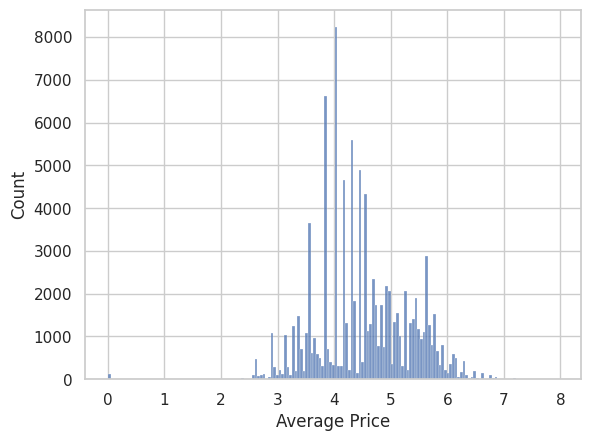

In [ ]:
fig = px.histogram(price_range, x='Price Range', nbins=30,
                   title='Distribution of Price Ranges Across Vegetables and Fruits')
fig.update_layout(xaxis_title='Price Range (Max - Min)', yaxis_title='Count of Vegetables')
fig.show()

# creating the histogram using Seaborn after applying log transformtion to reduce skewness
sns.histplot(np.log1p(df['Average Price']))


In [ ]:
# barchart of the price range
fig = px.bar(price_range.head(10), x='Vegetable', y='Price Range',
             title='Distribution of Top 10 Vegetables and Fruits by Price',
             labels={'Price Range': 'Price Range (NPR)'})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

## Box Plot and Barplot of Stable Vegetables and Fruits for Profit Prediction

In [ ]:
# create box plot of the top 10 vegetables with the lowest CV
# these are the most stable (least price fluctuation) vegetables/fruits
fig = px.box(std_cv.sort_values('CV').head(10),
             x='Vegetable', y='CV', points="all",
             title='Box Plot of Coefficient of Variation (Top 10 Stable Vegetables and Fruits)')

fig.update_layout(yaxis_title='CV (Std / Mean)', xaxis_tickangle=-45)
fig.show()


In [ ]:
# barplot of stablility in market
fig = px.bar(std_cv.head(10), x='Vegetable', y='CV',
             title='Top 10 Most Stable Vegetables and Fruits',
             labels={'CV': 'Coefficient of Variation'})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

## Histogram Analysis and Barplot of Year-on-Year Price Change (%)

In [ ]:
# Filtering out extreme YoY values
hist_df = avg_price_year.dropna()
hist_df = hist_df[(hist_df['YoY Change (%)'] > -100) & (hist_df['YoY Change (%)'] < 200)]

# Plotting
fig = px.histogram(hist_df, x='YoY Change (%)', nbins=50,
                   title='Distribution of Year-on-Year Price Change (%)')
fig.update_layout(xaxis_title='YoY Change (%)', yaxis_title='Frequency')
fig.show()



In [ ]:
# Including vegetables that only exist in both 2021 and 2022
valid_veg = avg_price_year.groupby('Vegetable')['Year'].nunique()
valid_veg = valid_veg[valid_veg > 1].index
yoy_filtered = avg_price_year[avg_price_year['Vegetable'].isin(valid_veg)]

# Focusing on 2022
yoy_2022 = yoy_filtered[yoy_filtered['Year'] == 2022]
yoy_2022 = yoy_2022[(yoy_2022['YoY Change (%)'] > -100) & (yoy_2022['YoY Change (%)'] < 200)]
yoy_2022 = yoy_2022.sort_values('YoY Change (%)', ascending=False)

fig = px.bar(yoy_2022.head(10), x='Vegetable', y='YoY Change (%)',
             title='Top 10 Vegetables by Year-on-Year Price Increase (2022)',
             labels={'YoY Change (%)': 'Change %'})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

## Box Plot and Barplot of Price Ranking (Average Price)

In [ ]:
# This shows the plot of 10 most frequently bought vegetables
fig = px.box(filtered_df,
             x='Vegetable',
             y='Average Price',
             points='all',  # Show all data points
             title='Price Distribution of Top 10 Frequent Vegetables')

fig.update_layout(
    xaxis_title='Vegetable',
    yaxis_title='Average Price (NPR)',
    xaxis_tickangle=45,
    height=600
)

fig.show()


In [ ]:
# bar plot of most expensive vegetables by price in the market
fig = px.bar(price_rank.head(10), x='Vegetable', y='Average Price',
             title='Top 10 Most Expensive Vegetables by Average Price',
             labels={'Average Price': 'Avg Price (NPR)'})
fig.update_layout(xaxis_tickangle=-45)
fig.show()

# Prediction Model Building

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Load cleaned data
df = pd.read_csv('/content/drive/MyDrive/kalimati_cleaned .csv')

# 🧹 Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Unit'] = df['Unit'].astype('category').cat.codes

# Features and Target
features = ['Minimum Price', 'Maximum Price', 'Unit', 'Year']
target = 'Average Price'
X = df[features]
y = df[target]

#  K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Cross-validation metrics
neg_mse_scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kf)
mse_scores = -neg_mse_scores  # Convert to positive MSE
rmse_scores = np.sqrt(mse_scores)
r2_scores = cross_val_score(model, X, y, scoring='r2', cv=kf)

#  Print Evaluation Results
print("🔸 MSE Scores for each fold:", mse_scores)
print("Average MSE:", mse_scores.mean())
print("Standard Deviation of MSE:", mse_scores.std())

print("\n🔸 RMSE Scores for each fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())
print("Standard Deviation of RMSE:", rmse_scores.std())

print("\n🔸 R² Scores for each fold:", r2_scores)
print("Average R² Score:", r2_scores.mean())
print("Standard Deviation of R² Scores:", r2_scores.std())


🔸 MSE Scores for each fold: [ 4.88485175  1.56373807 45.19328376 51.51739356 13.8844398 ]
Average MSE: 23.408741387578903
Standard Deviation of MSE: 20.860074740061293

🔸 RMSE Scores for each fold: [2.21017007 1.25049513 6.72259502 7.17756181 3.72618301]
Average RMSE: 4.217401007705609
Standard Deviation of RMSE: 2.371132667689137

🔸 R² Scores for each fold: [0.99967846 0.9998917  0.99691359 0.9965773  0.99902982]
Average R² Score: 0.9984181740823084
Standard Deviation of R² Scores: 0.0013990216967288698


## Visualizing K-Fold Cross Verification on the Random Forest Regressor Model

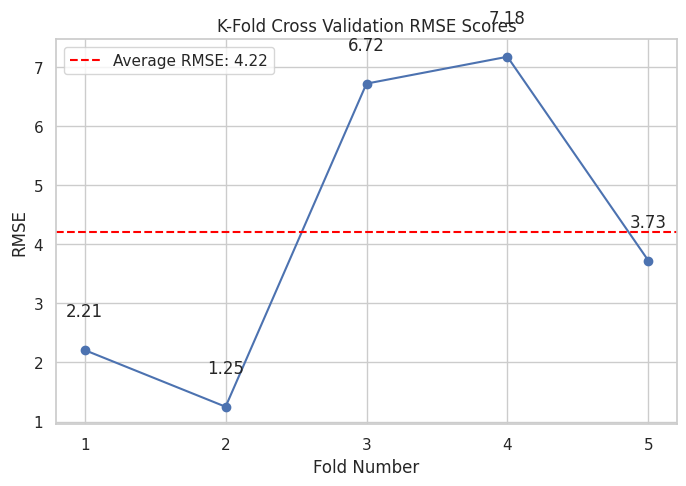

In [ ]:
# Set style
sns.set(style="whitegrid")

# Plot line chart of RMSE across folds
plt.figure(figsize=(8,5))
plt.plot(range(1, len(rmse_scores)+1), rmse_scores, marker='o', linestyle='-', color='b')

plt.title('K-Fold Cross Validation RMSE Scores')
plt.xlabel('Fold Number')
plt.ylabel('RMSE')
plt.xticks(range(1, len(rmse_scores)+1))  # ensure x-axis shows 1,2,3,4,5

# Add horizontal line for average RMSE
plt.axhline(y=rmse_scores.mean(), color='red', linestyle='--', label=f'Average RMSE: {rmse_scores.mean():.2f}')
plt.legend()

# Annotate points
for i, score in enumerate(rmse_scores, 1):
    plt.text(i, score + 0.5, f"{score:.2f}", ha='center', va='bottom')

plt.show()

## K-Means Clustering Model

               Vegetable  Minimum Price  Maximum Price  Average Price  Cluster
0                   Amla      79.634703      90.502283      85.503151        0
1            Apple(Fuji)     258.679342     291.957862     275.738869        1
2          Apple(Jholey)     190.483871     211.244240     200.994562        2
3                   Arum      45.977860      55.565806      51.044982        0
4              Asparagus     490.223208     549.494653     531.494007        1
..                   ...            ...            ...            ...      ...
128               Turnip      61.400651      71.400651      66.843436        0
129             Turnip A      69.880565      79.880565      75.255179        0
130  Water Melon(Dotted)      33.181818      39.772727      36.741364        0
131   Water Melon(Green)      53.441176      62.581136      58.344554        0
132                  Yam      60.486284      70.698254      65.899127        0

[133 rows x 5 columns]


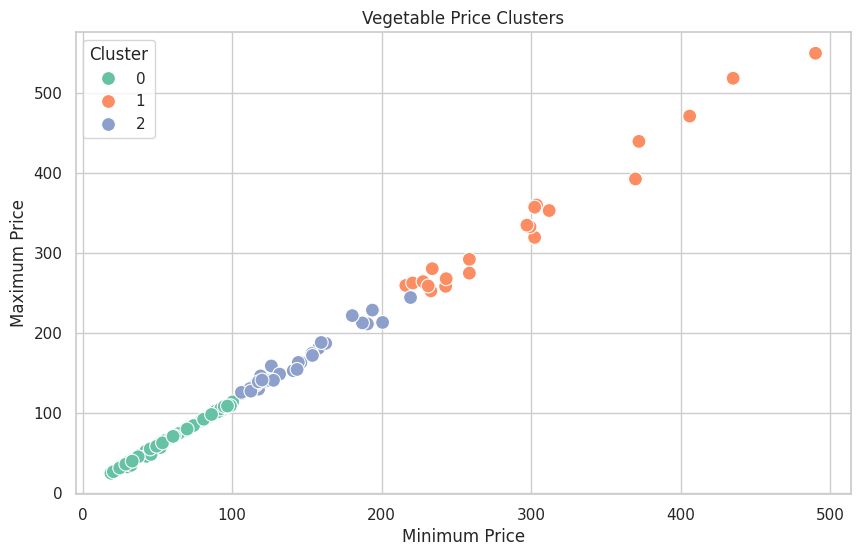

In [ ]:
# Load data
df = pd.read_csv('/content/drive/MyDrive/kalimati_cleaned .csv')

# Convert price columns to numeric, coercing errors
price_cols = ['Minimum Price', 'Maximum Price', 'Average Price']
for col in price_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing prices
df = df.dropna(subset=price_cols)

# Group by vegetable name (correct column), averaging prices
avg_price_df = df.groupby('Vegetable')[price_cols].mean().reset_index()

# Standardizing the numeric features
X = avg_price_df[price_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
avg_price_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Showing all grouped vegetables (remove head to see full)
print(avg_price_df)

# Visualizing clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=avg_price_df, x='Minimum Price', y='Maximum Price', hue='Cluster', palette='Set2', s=100)
plt.title('Vegetable Price Clusters')
plt.show()

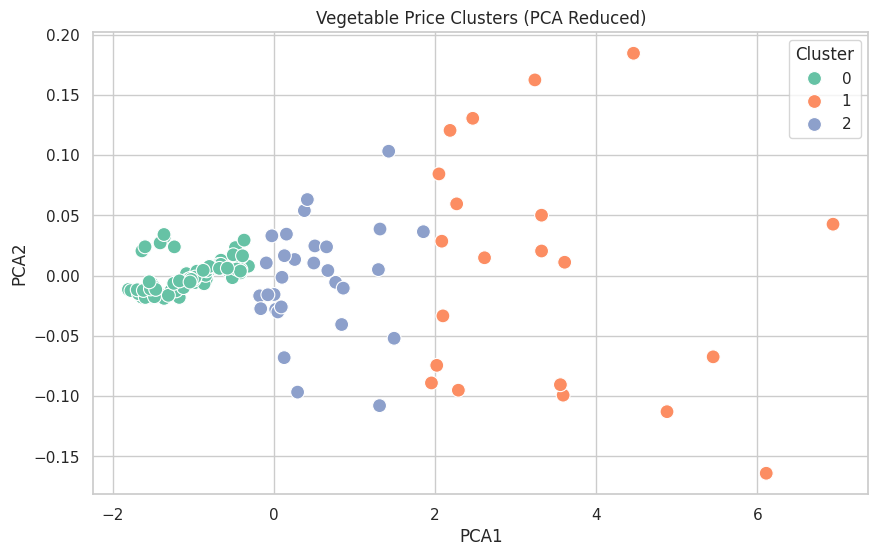

In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2D
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Add PCA components to DataFrame
avg_price_df['PCA1'] = components[:, 0]
avg_price_df['PCA2'] = components[:, 1]

# Plot PCA-reduced clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=avg_price_df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
plt.title('Vegetable Price Clusters (PCA Reduced)')
plt.show()

## Accuracy Testing

In [ ]:

# Inertia (Within-Cluster Sum of Squares)
print(f'Inertia (WCSS): {kmeans.inertia_:.2f}')

# Silhouette Score (requires labels and original data)
sil_score = silhouette_score(X_scaled, avg_price_df['Cluster'])
print(f'Silhouette Score: {sil_score:.4f}')

Inertia (WCSS): 65.63
Silhouette Score: 0.5861


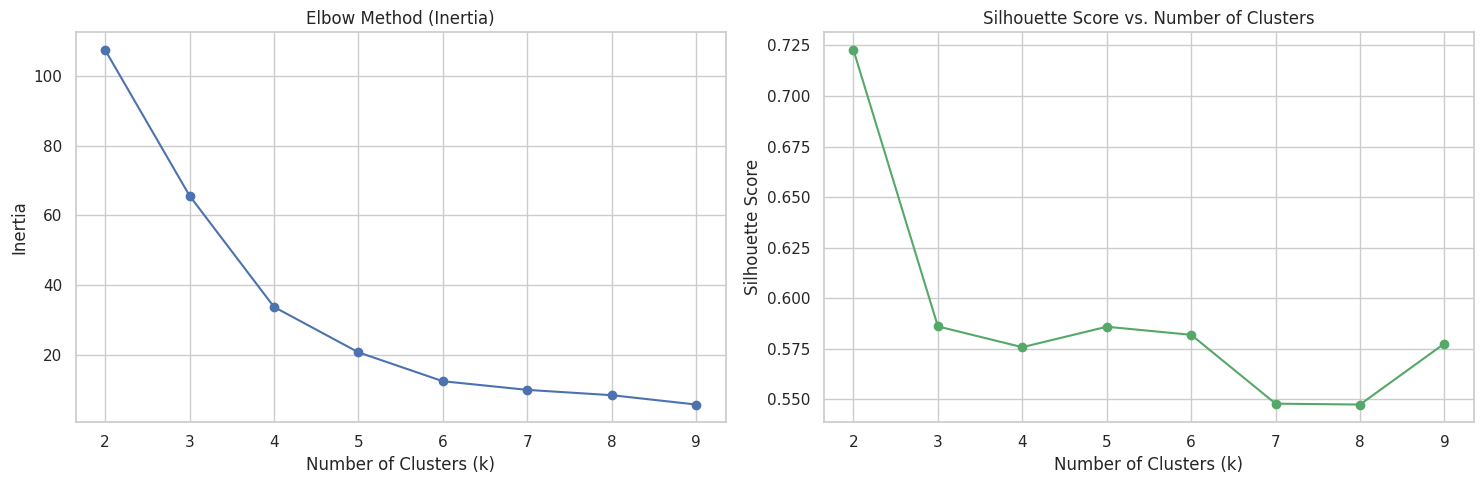


Final KMeans Model (k=3)
Inertia: 65.63
Silhouette Score: 0.5861

Cluster Summary:
         Minimum Price  Maximum Price  Average Price
Cluster                                             
0            60.706331      70.200388      65.724251
1           297.903793     337.946678     318.737812
2           143.643657     164.354584     154.247145


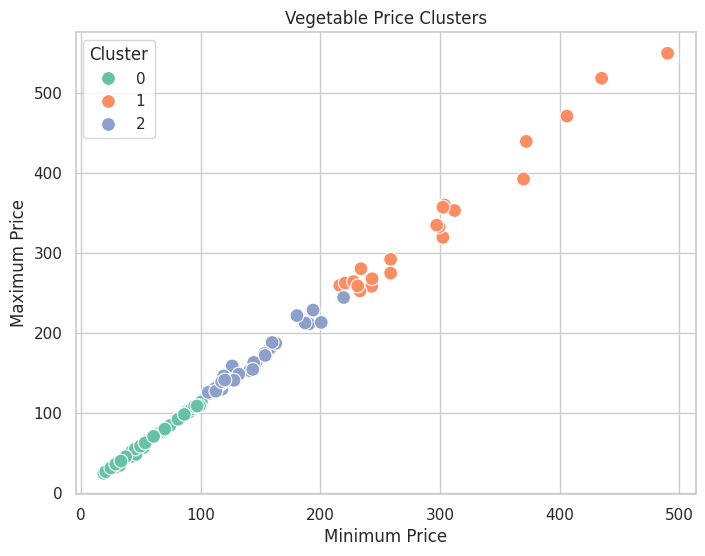

In [ ]:
# Initialize values for plotting
inertias = []
sil_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow and Silhouette
plt.figure(figsize=(15, 5))

# Inertia plot
plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Inertia)')

# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, 'go-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')

plt.tight_layout()
plt.show()

# Fit final model with chosen k (e.g., k=3)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
avg_price_df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Final metrics
print(f"\nFinal KMeans Model (k={optimal_k})")
print(f"Inertia: {kmeans_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, avg_price_df['Cluster']):.4f}")

# Cluster Profiling Summary
print("\nCluster Summary:")
print(avg_price_df.groupby('Cluster')[price_cols].mean())

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=avg_price_df, x='Minimum Price', y='Maximum Price',
                hue='Cluster', palette='Set2', s=100)
plt.title('Vegetable Price Clusters')
plt.xlabel('Minimum Price')
plt.ylabel('Maximum Price')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()